# Importation

In [1]:
import io
from qubic.lib.Qscene import QubicScene
from qubic.lib.Instrument.Qnoise import QubicTotNoise
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Image as IPyImage
from PIL import Image
from pyoperators import (
    MPI,
    BlockColumnOperator,
    BlockDiagonalOperator,
    BlockRowOperator,
    CompositionOperator,
    DenseOperator,
    DiagonalOperator,
    IdentityOperator,
    PackOperator,
    Operator,
    ReshapeOperator,
    flags,
)
from pyoperators.iterative.core import AbnormalStopIteration
from pysimulators.interfaces.healpy import (
    Spherical2HealpixOperator,
)
from scipy.optimize import minimize

import qubic
from qubic.lib.Instrument.Qacquisition import QubicInstrumentType
from qubic.lib.MapMaking.Qatmosphere import AtmosphereMaps, WindPerturbation
from qubic.lib.MapMaking.Qcg_test_for_atm import PCGAlgorithm
from qubic.lib.Qsamplings import QubicSampling, equ2gal, get_pointing

comm = MPI.COMM_WORLD
rank = comm.Get_rank()

%matplotlib inline

In [2]:
# Import simulation parameters
with open("params.yml", "r") as file:
    params = yaml.safe_load(file)

np.random.seed(params["seed"])

In [3]:
# Call the class which build the atmosphere maps
atm = AtmosphereMaps(params)
qubic_dict = atm.qubic_dict
qubic_dict["instrument_type"] = "UWB"
qubic_dict["interp_projection"] = False

npix = hp.nside2npix(params["nside"])

center = np.array([0, -57])
qubic_patch = qubic.lib.Qsamplings.equ2gal(center[0], center[1])

# Mixing Matrix

(8, 2)


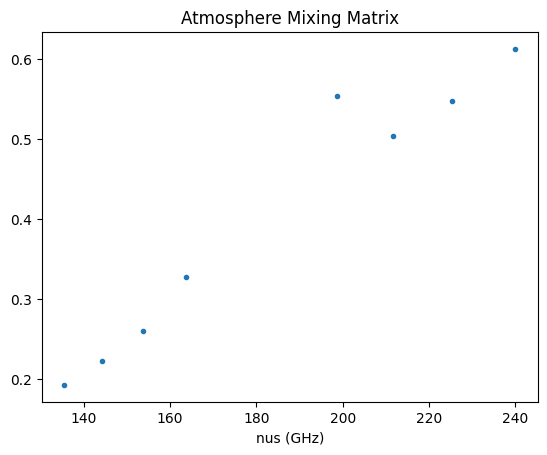

In [4]:
mixing_matrix = np.ones((params["nsub_in"], 2))
# Atm mixing matrix
mixing_matrix[:, 1] = atm.temperature * atm.integrated_abs_spectrum * atm.mean_water_vapor_density
print(mixing_matrix.shape)

plt.plot(atm.frequencies, mixing_matrix[:, 1], ".")
plt.xlabel("nus (GHz)")
plt.title("Atmosphere Mixing Matrix")
plt.show()

# Scanning Strategy

In [5]:
### Random pointing
qubic_dict["random_pointing"] = True
qubic_dict["date_obs"] = "2023-10-01 22:57:00.000"
qubic_dict["period"] = 3
qubic_dict["fix_azimuth"]["apply"] = False

### Sweeping pointing
if params["sweeping_pointings"]:
    qubic_dict["random_pointing"] = False
    qubic_dict["sweeping_pointing"] = True

    qubic_dict["angspeed"] = 0.1
    qubic_dict["delta_az"] = 20
    qubic_dict["nsweeps_per_elevation"] = 1
    qubic_dict["duration"] = 1
    # npointings = 3600 * qubic_dict['duration'] / qubic_dict['period']
    qubic_dict["period"] = 3600 * qubic_dict["duration"] / params["npointings"]

### Repeat pointing
# qubic_dict["repeat_pointing"] = False

### Build scanning strategy instance
q_sampling_gal = get_pointing(qubic_dict)
qubic_patch = np.array([0, -57])
center_gal = equ2gal(qubic_patch[0], qubic_patch[1])
center_local = np.array([np.mean(q_sampling_gal.azimuth), np.mean(q_sampling_gal.elevation)])

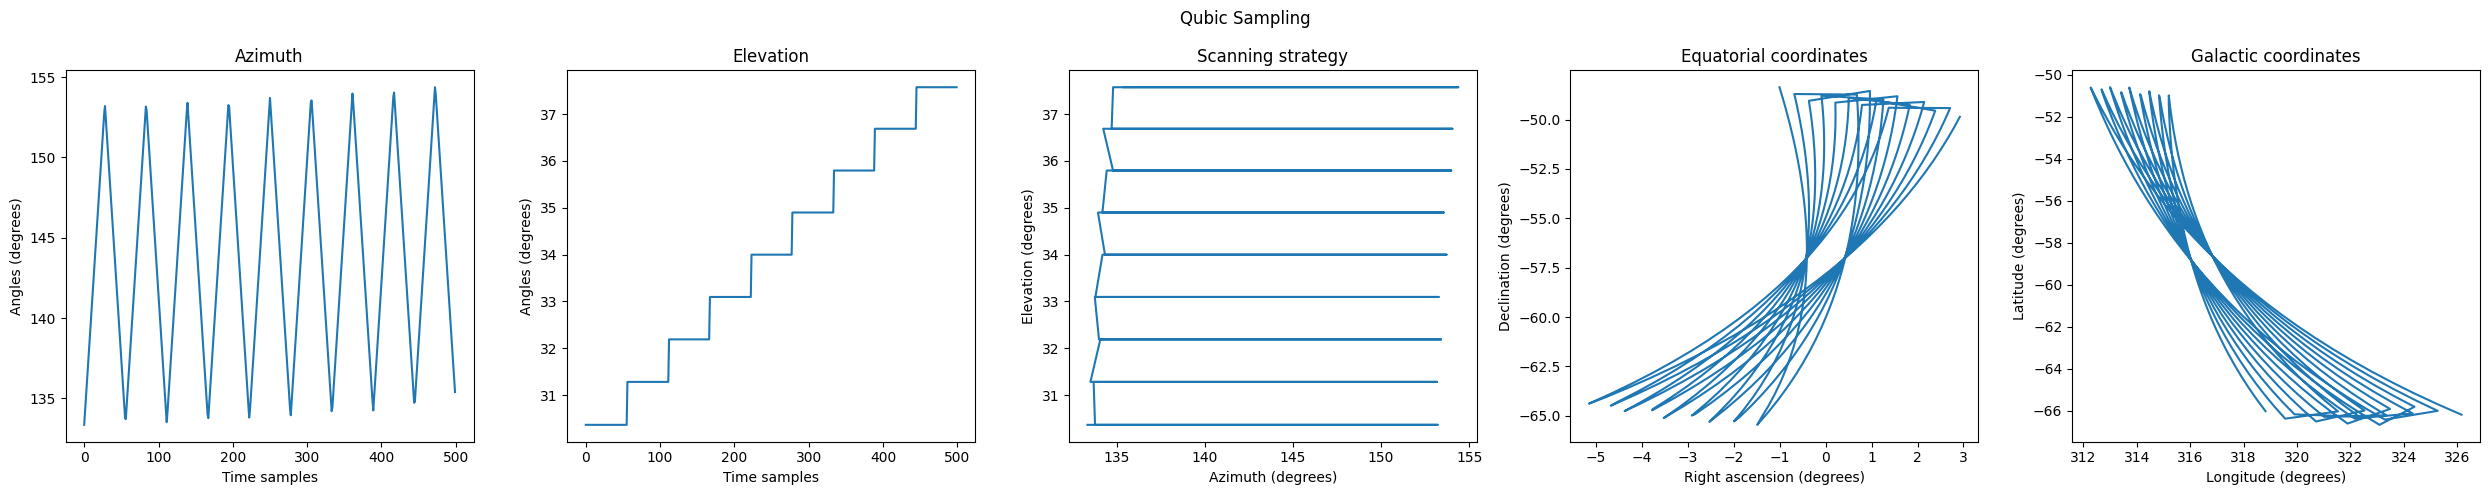

In [6]:
### Plot scanning strategy
az, el = q_sampling_gal.azimuth, q_sampling_gal.elevation

fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# Azimuth plot
axs[0].plot(az)
axs[0].set_title("Azimuth")
axs[0].set_xlabel("Time samples")
axs[0].set_ylabel("Angles (degrees)")

# Elevation plot
axs[1].plot(el)
axs[1].set_title("Elevation")
axs[1].set_xlabel("Time samples")
axs[1].set_ylabel("Angles (degrees)")

# Scanning strategy plot
axs[2].plot(az, el)
axs[2].set_title("Scanning strategy")
axs[2].set_xlabel("Azimuth (degrees)")
axs[2].set_ylabel("Elevation (degrees)")

# Equatorial coordinates plot
axs[3].plot((q_sampling_gal.equatorial[:, 0] + 180) % 360 - 180, q_sampling_gal.equatorial[:, 1])
axs[3].set_title("Equatorial coordinates")
axs[3].set_xlabel("Right ascension (degrees)")
axs[3].set_ylabel("Declination (degrees)")

# Galactic coordinates plot
axs[4].plot(q_sampling_gal.galactic[:, 0], q_sampling_gal.galactic[:, 1])
axs[4].set_title("Galactic coordinates")
axs[4].set_xlabel("Longitude (degrees)")
axs[4].set_ylabel("Latitude (degrees)")

fig.suptitle("Qubic Sampling")
plt.tight_layout()
plt.show()

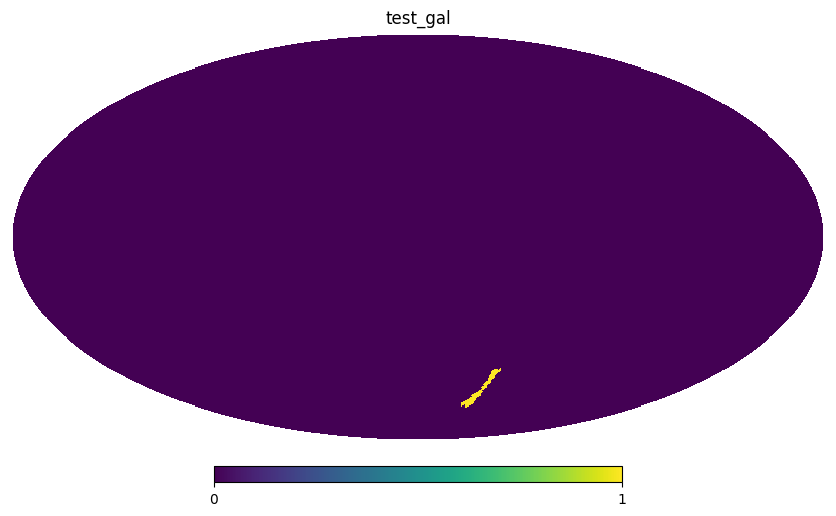

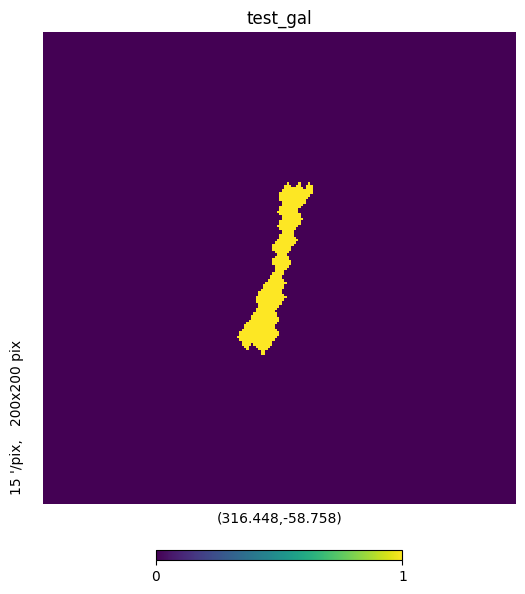

In [7]:
### Test scanning strategy plots
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians(q_sampling_gal.galactic)
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_gal", cmap="viridis")
hp.gnomview(test_gal, title="test_gal", cmap="viridis", reso=15, rot=center_gal)

## Build local sampling

In [8]:
### Define scanning strategy for atm observation
q_sampling_local_rec = QubicSampling(
    q_sampling_gal.index.size,
    date_obs=qubic_dict["date_obs"],
    period=qubic_dict["period"],
    latitude=qubic_dict["latitude"],
    longitude=qubic_dict["longitude"],
)

q_sampling_local_rec.azimuth = q_sampling_gal.azimuth
q_sampling_local_rec.elevation = q_sampling_gal.elevation
q_sampling_local_rec.pitch = q_sampling_gal.pitch
q_sampling_local_rec.angle_hwp = q_sampling_gal.angle_hwp

q_sampling_local_rec.fix_az = True

if params["wind"]:
    wind_class = WindPerturbation(params, q_sampling_gal)
    q_sampling_local = wind_class.get_deviated_qubic_sampling()
else:
    q_sampling_local = q_sampling_local_rec

143.80975773846924 32.5451999846756


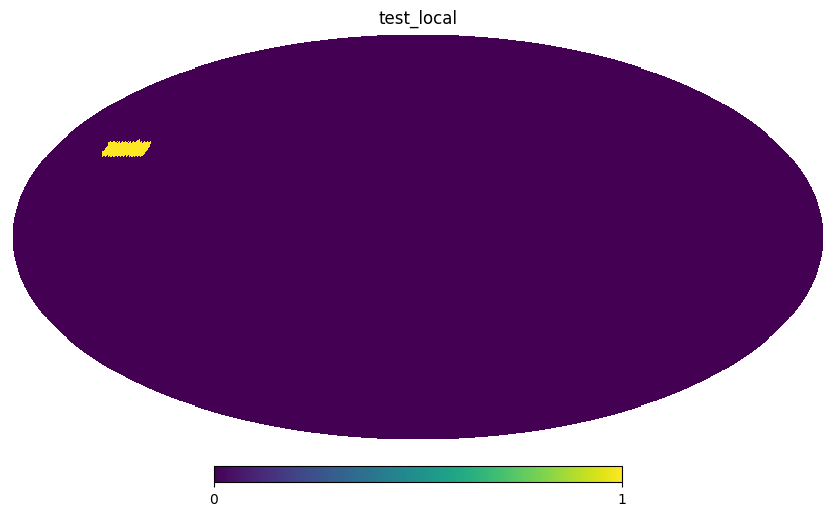

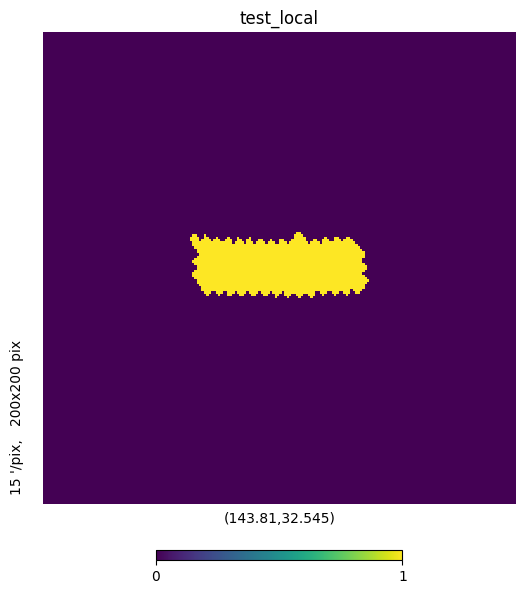

In [9]:
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians([q_sampling_local.azimuth, q_sampling_local.elevation]).T
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_local", cmap="viridis")
hp.gnomview(
    test_gal,
    title="test_local",
    cmap="viridis",
    reso=15,
    rot=(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation)),
)

print(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation))

143.80975773846924 32.5451999846756


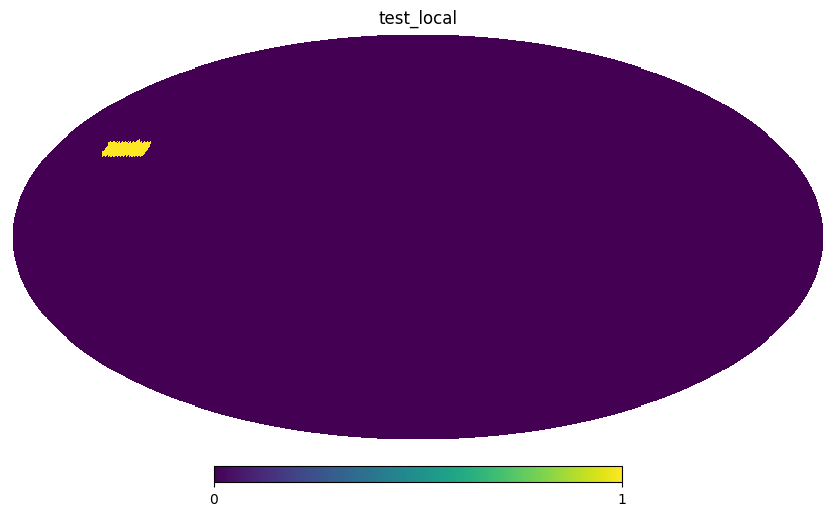

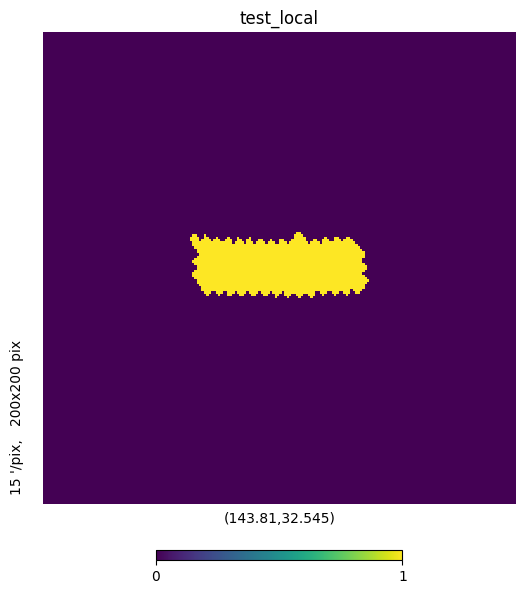

In [10]:
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians([q_sampling_local.azimuth, q_sampling_local.elevation]).T
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_local", cmap="viridis")
hp.gnomview(
    test_gal,
    title="test_local",
    cmap="viridis",
    reso=15,
    rot=(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation)),
)

print(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation))

## Build 1 pointing sampling list

In [11]:
print(q_sampling_local)

QubicSampling((500,), 
    index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15 ,
    angle_hwp=[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ,
    azimuth=[133.34925326 134.06960267 134.78996052 135.51032682 136.23070157,
    elevation=[30.36132616 30.35559658 30.349867   30.34413742 30.33840784 30.3,
    equatorial=[[104.42846081 -48.36416708]
 [104.51694618 -48.9845703 ]
 [104.6,
    galactic=[[258.33079217 -18.94160104]
 [258.96921937 -19.09655709]
 [259.6,
    masked=False,
    pitch=[-10.    -9.28  -8.56  -7.84  -7.12  -6.4   -5.68  -4.96  -4.24  ,
    time=[   0.     7.2   14.4   21.6   28.8   36.    43.2   50.4   57.6  )


In [12]:
q_sampling = []

N_buffer = 10

for ipointing in range(int(params["npointings"] / N_buffer)):
    tmp = QubicSampling(N_buffer)
    tmp.azimuth = q_sampling_gal.azimuth[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.elevation = q_sampling_gal.elevation[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.pitch = q_sampling_gal.pitch[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.angle_hwp = q_sampling_gal.angle_hwp[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.fix_az = True
    q_sampling.append(tmp)

# Atm

(8, 49152, 3)


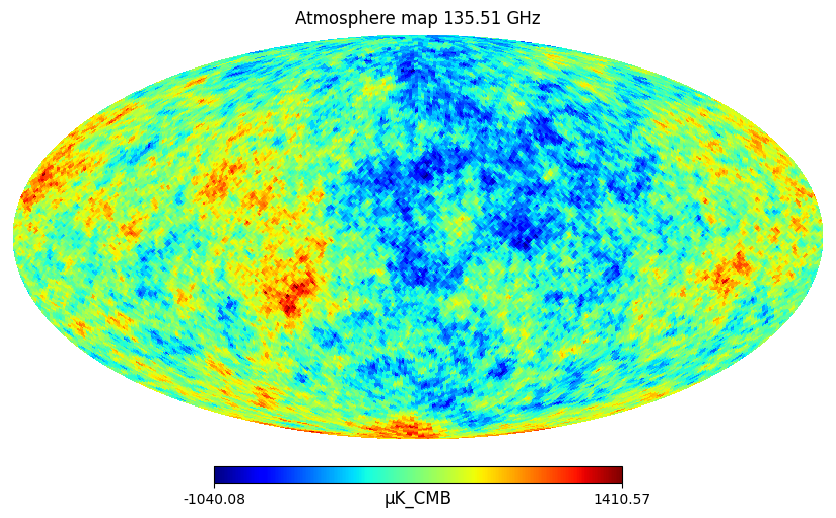

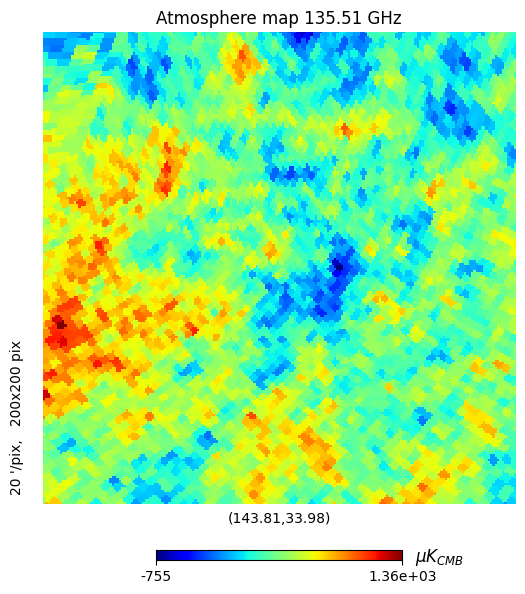

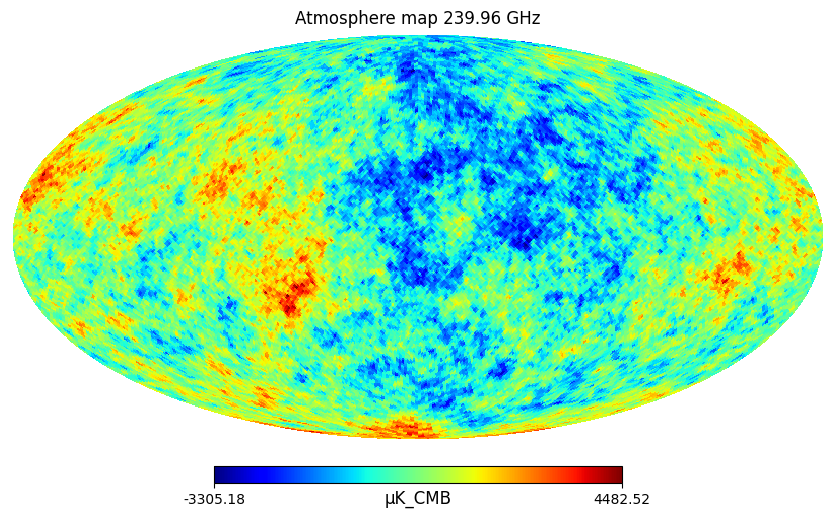

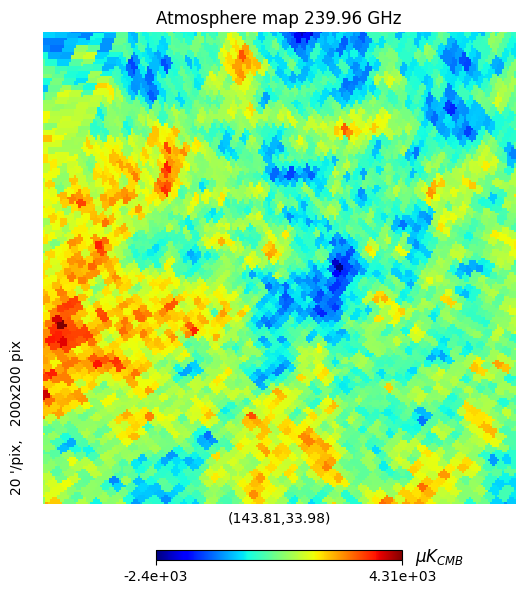

In [13]:
atm_maps = np.zeros((params["nsub_in"], hp.nside2npix(params["nside"]), 3))
atm_maps[..., 0] = atm.get_temp_maps(atm.delta_rho_map) / 1e3
print(atm_maps.shape)

index_nu = 0
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

index_nu = -1
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

In [14]:
true_maps = atm_maps.mean(axis=0)[None]
print(true_maps.shape)

min_input = np.min(true_maps, axis=1)
max_input = np.max(true_maps, axis=1)

max = np.max([min_input, max_input], axis=0)
min_input = -max
max_input = max

(1, 49152, 3)


# Map-making

## Tod acquisition

In [15]:
# Build the QUBIC operators
H_tod = QubicInstrumentType(
    atm.qubic_dict, nsub=params["nsub_in"], nrec=params["nsub_in"], sampling=q_sampling_local
).get_operator()
qubic_scene = QubicScene(qubic_dict)
qubic_noise = QubicTotNoise(qubic_dict, q_sampling_gal, qubic_scene)
tod = H_tod(atm_maps).ravel() + qubic_noise.total_noise(1, 1, 1, seed_noise=params["seed"]).ravel()
print(tod.shape)

del H_tod

Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Duration at 150 GHz is 3 yrs
Duration at 220 GHz is 3 yrs
(496000,)


## Rec acquisition

In [16]:
Qacq = QubicInstrumentType(
    qubic_dict, params["nsub_in"], params["nsub_in"], sampling=q_sampling_local_rec
)

# 1 pointing acq
H_rec = []
invN_rec = []

for ipointing in range(int(params["npointings"] / N_buffer)):
    tmp = QubicInstrumentType(
        qubic_dict, params["nsub_rec"], params["nsub_rec"], sampling=q_sampling[ipointing]
    )
    H_rec.append(tmp.get_operator())
    invN_rec.append(tmp.get_invntt_operator(params["wdet"], params["wpho150"], params["wpho220"]))

Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__in

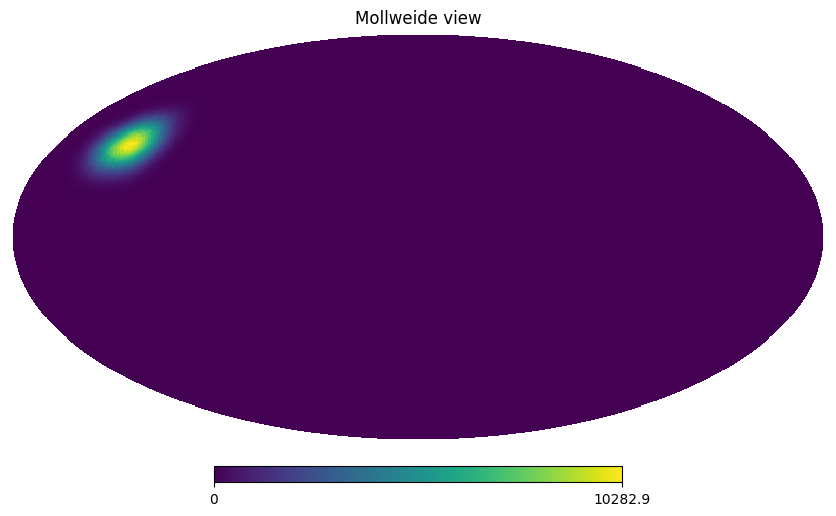

In [17]:
coverage = Qacq.coverage

covnorm = coverage / coverage.max()
seenpix = covnorm > params["coverage_cut"]

hp.mollview(coverage)

# Wind Operator

In [18]:
@flags.linear
@flags.square
class ShiftOperator(Operator):
    """
    PyOperator wrapping rotate_healpy_map_by_wind.
    Applies a sky rotation defined by a 2D wind vector (wx, wy).
    """

    def __init__(self, wind, dtype=None, **keywords):
        # Always call parent __init__ first in PyOperators subclasses
        Operator.__init__(self, dtype=dtype, **keywords)
        self.wind = np.asarray(wind, dtype=float)  # (wx, wy)

    def direct(self, input_map, out):
        wind_x, wind_y = self.wind
        m_rot = wind_class.shift_healpy_map(input_map, wind_x, wind_y, verbose=False)
        out[...] = m_rot

    def transpose(self, input_map, out):
        wind_x, wind_y = self.wind
        m_rot = wind_class.shift_healpy_map(input_map, -wind_x, -wind_y, verbose=False)
        out[...] = m_rot


def get_wind_operator(
    wind,
    Npointings=params["npointings"],
    Nsub=params["nsub_rec"],
    N_buffer=N_buffer,
    nside=params["nside"],
):
    npix = hp.nside2npix(nside)
    shape = (Nsub, npix, 3)
    wind_x, wind_y = wind

    # Convert scalar wind speed to cumulative displacement, matching get_constant_wind
    if np.isscalar(wind_x):
        wind_x = wind_x * np.cumsum(np.ones(Npointings, dtype=float))
    if np.isscalar(wind_y):
        wind_y = wind_y * np.cumsum(np.ones(Npointings, dtype=float))

    chunks = range(0, Npointings, N_buffer)

    tmp = []
    for i in chunks:
        wx_chunk = float(np.mean(wind_x[i : i + N_buffer]))
        wy_chunk = float(np.mean(wind_y[i : i + N_buffer]))

        tmp.append(
            ShiftOperator(
                wind=(wx_chunk, wy_chunk),
                shapein=shape,
                shapeout=shape,
            )
        )

    return BlockColumnOperator(tmp, axisout=0)


# Expected output shape: (n_chunks * nsub_rec, npix, 3)
n_chunks = len(range(0, params["npointings"], N_buffer))
print("Expected output shape:", (n_chunks * params["nsub_rec"], npix, 3))

shift_test = get_wind_operator(wind_class.get_wind(), Npointings=params["npointings"], Nsub=1)

print("shift:", shift_test.shapein, "→", shift_test.shapeout)

Expected output shape: (400, 49152, 3)
shift: (1, 49152, 3) → (50, 49152, 3)


In [19]:
@flags.linear
class PermuteChunksOperator(Operator):
    """
    Reorder TOD from BlockDiagonalOperator's (n_chunks, D, N_buffer) layout
    to the full-acquisition (D, n_chunks, N_buffer) = (D, Npointings) layout.

    BlockDiagonalOperator concatenates per-chunk outputs naively, so chunk 0's
    detectors come before chunk 1's detectors.  The full H_tod operator instead
    produces all time samples for each detector consecutively.  This operator
    corrects that axis swap.

    Direct:    chunked ordering → full ordering   (axes 0↔1 of the 3-D view)
    Transpose: full ordering    → chunked ordering
    """

    def __init__(self, n_chunks, D, N_buffer, **keywords):
        self.n_chunks = n_chunks
        self.D = D
        self.N_buffer = N_buffer
        N = n_chunks * D * N_buffer
        Operator.__init__(self, shapein=(N,), shapeout=(N,), **keywords)

    def direct(self, input, out):
        nc, D, Nb = self.n_chunks, self.D, self.N_buffer
        out[...] = input.reshape(nc, D, Nb).transpose(1, 0, 2).ravel()

    def transpose(self, input, out):
        nc, D, Nb = self.n_chunks, self.D, self.N_buffer
        out[...] = input.reshape(D, nc, Nb).transpose(1, 0, 2).ravel()


In [20]:
def create_mollview_gif(maps, duration=100):
    """
    Create a GIF from a sequence of HEALPix maps and display it inline (no file saved).

    Parameters:
    -----------
    maps : list of np.ndarray
        List of HEALPix maps to animate.
    duration : int
        Time between frames in milliseconds.

    Returns:
    --------
    IPython.display.Image object (displays automatically in notebook)
    """
    frames = []
    range = np.max([-np.min(maps[0]), np.max(maps[0])])

    for i, m in enumerate(maps):
        fig = plt.figure(figsize=(10, 6))
        hp.mollview(m, fig=fig, title=f"Frame {i + 1}", unit="K", cmap="jet", min=-range, max=range)

        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=100, bbox_inches="tight")
        buf.seek(0)
        frames.append(Image.open(buf))
        plt.close(fig)

    # Save to an in-memory bytes buffer
    gif_buffer = io.BytesIO()
    frames[0].save(
        gif_buffer,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0,
        optimize=True,
        format="GIF",
    )
    gif_buffer.seek(0)

    # Return an IPython Image object (will be displayed automatically)
    return IPyImage(data=gif_buffer.getvalue())

In [21]:
# test = shift_test(true_maps)
# print(test.shape)

# create_mollview_gif(test[..., 0])

# Rec Operator

In [23]:
Amm = DenseOperator(
    mixing_matrix[:, 1, None],
    broadcast="rightward",
    shapein=(1, npix, 3),
    shapeout=(params["nsub_in"], npix, 3),
)
print("A :", Amm.shapein, Amm.shapeout)

shift = get_wind_operator(
    wind_class.get_wind(),
    Npointings=params["npointings"],
    Nsub=params["nsub_rec"],
    nside=params["nside"],
)

print("W : ", shift.shapein, shift.shapeout)

A : (1, 49152, 3) (8, 49152, 3)
W :  (8, 49152, 3) (400, 49152, 3)


In [24]:
H_ = BlockDiagonalOperator(H_rec, axisin=0)
print("H_ :", H_.shapein, H_.shapeout)
print("W :", shift.shapein, shift.shapeout)
print("A :", Amm.shapein, Amm.shapeout)
print("W * A : ", (shift * Amm).shapein, (shift * Amm).shapeout)

# D = nsub * Ndet (number of "virtual detectors" per time sample)
n_chunks = params["npointings"] // N_buffer
D = tod.size // params["npointings"]

# Permutation operator: converts BlockDiagonalOperator's (n_chunks, D, N_buffer)
# ordering to the full-acquisition (D, Npointings) ordering.
Pchunk = PermuteChunksOperator(n_chunks, D, N_buffer)

H = Pchunk * H_ * shift * Amm

# Noise operator: apply Pchunk so it lives in the same (full) ordering as H.
R_chunk = ReshapeOperator(
    (n_chunks * D, N_buffer),
    (n_chunks * D * N_buffer,),
)
inv_rec = BlockDiagonalOperator(invN_rec, axisout=0)
invN = Pchunk * R_chunk * inv_rec * R_chunk.T * Pchunk.T

print("H :", H.shapein, H.shapeout)
print("invN :", invN.shapein, invN.shapeout)

wind_rec = (0, 0)
wind_true = params["wind_cst"]


H_ : (400, 49152, 3) (496000,)
W : (8, 49152, 3) (400, 49152, 3)
A : (1, 49152, 3) (8, 49152, 3)
W * A :  (1, 49152, 3) (400, 49152, 3)
H : (1, 49152, 3) (496000,)
invN : (496000,) (496000,)


In [25]:
# Build PCG
R = ReshapeOperator(tod.shape, H.shapeout)
A = H.T * invN * H
b = H.T * invN * R(tod)
x0 = true_maps  # * 0.0

In [26]:
print("A", A.shapein, A.shapeout)
print("b", b.shape)
print("x0", x0.shape)

A (1, 49152, 3) (1, 49152, 3)
b (1, 49152, 3)
x0 (1, 49152, 3)


In [ ]:
def call_pcg(A, b, x0, max_iter=5, M=None):
    algo = PCGAlgorithm(
        A,
        b,
        comm,
        x0=x0,
        tol=1e-12,
        maxiter=max_iter,
        disp=True,
        M=M,
        center=[0, -57],
        reso=15,
        seenpix=seenpix,
        input=true_maps,
    )
    try:
        result = algo.run()
        success = True
        message = "Success"
    except AbnormalStopIteration as e:
        result = algo.finalize()
        success = False
        message = str(e)

    return result


def get_chi2(x, tod):
    wind = get_wind_operator(x)
    tod_sim = Pchunk * H_ * wind * Amm * P(maps_rec)
    res = tod - tod_sim
    return 0.5 * np.dot(res.T, invN(res))


def debug_chi2(x0, tod, eps=0.05):
    """Central-difference gradient diagnostic for get_chi2."""
    x0 = np.asarray(x0, dtype=float)
    chi2_0 = get_chi2(x0, tod)
    print(f"  chi2({x0}) = {chi2_0:.6e}")
    grad = np.zeros_like(x0)
    for i in range(len(x0)):
        xp = x0.copy()
        xp[i] += eps
        xm = x0.copy()
        xm[i] -= eps
        cp = get_chi2(xp, tod)
        cm = get_chi2(xm, tod)
        grad[i] = (cp - cm) / (2 * eps)
        print(f"  chi2(x[{i}]+eps)={cp:.6e}  chi2(x[{i}]-eps)={cm:.6e}  grad[{i}]={grad[i]:.4e}")
    print(f"  gradient = {grad}  (norm={np.linalg.norm(grad):.4e})")
    return chi2_0, grad


def _chi2_grad(x, tod, eps, scale):
    """Central-difference gradient, divided by scale to keep values O(1)."""
    g = np.zeros_like(x)
    for i in range(len(x)):
        xp = x.copy()
        xp[i] += eps
        xm = x.copy()
        xm[i] -= eps
        g[i] = (get_chi2(xp, tod) - get_chi2(xm, tod)) / (2 * eps * scale)
    return g


def fit_wind(tod, eps=0.05):
    x0 = np.asarray(wind_rec, dtype=float)

    print(f"  [wind diag] running debug_chi2 at x0={x0} ...")
    chi2_0, grad_0 = debug_chi2(x0, tod, eps=eps)

    scale = np.max([chi2_0, 1.0])

    result = minimize(
        lambda x, t: get_chi2(x, t) / scale,
        x0=x0,
        jac=lambda x, t: _chi2_grad(x, t, eps=eps, scale=scale),
        method="L-BFGS-B",
        args=tod,
        bounds=[(-5, 5), (-5, 5)],
        options={"ftol": 1e-30, "gtol": 1e-10, "maxiter": 100},
    )
    print(f"  [wind diag] optimizer: success={result.success}, nfev={result.nfev}, "
          f"x={result.x}, chi2={result.fun * scale:.4e}, msg={result.message}")
    return result.x


# Run Map-Making

In [28]:
# Fix CMB Intensity + Atm Polarisation
mask = np.ones(true_maps.shape)  # Mask for 2 components : CMB & Atm
print(mask.shape)
if params["cmb"] and not params["atm"]:
    mask[..., 0] = 0  # CMB Intensity
elif params["cmb"] and params["atm"]:
    mask[0, :, 0] = 0
    mask[1, :, [1, 2]] = 0  # Atm Polarisation
elif not params["cmb"] and params["atm"]:
    mask[..., [1, 2]] = 0
if params["fix_maps"]:
    P = PackOperator(mask).T  # Build Mask Operator
else:
    P = IdentityOperator()
x_masked = true_maps * (1 - mask)
print("P : ", P.shapein, P.shapeout)

# Start from uniform mixing-matrix (= 1)
mixing_matrix_rec = np.ones_like(mixing_matrix)
wind_op = get_wind_operator(wind_rec)

# Preconditioner
M = None

(1, 49152, 3)
P :  (49152,) (1, 49152, 3)


In [29]:
# Run PCG
convergence = []
wind_iter = [wind_rec]
maps_rec = P.T(true_maps) / mixing_matrix[:, 1].mean()
print(maps_rec.shape)

# Reconstruction loop
for iloop in range(params["n_loop"]):
    print("=====================================")
    print("Iteration : ", iloop)

    ### fit pixels
    print("-------------------------------------")
    print("Fit Maps :")
    print("-------------------------------------")
    H = Pchunk * H_ * wind_op * Amm
    A = P.T * H.T * invN * H * P
    b = P.T * H.T * invN * (tod - H(x_masked))

    if params["iterative_iter"]:
        n_iter = iloop
    else:
        n_iter = params["n_iter"]

    result = call_pcg(A, b, maps_rec, max_iter=n_iter, M=M)
    convergence.append(result["convergence"])
    output = result["x"].copy()
    print("Previous Maps: ", maps_rec.mean(axis=0))

    if params["fix_maps"]:
        if params["cmb"] and params["atm"]:
            maps_rec[0, :, 1:] = output[: npix * 2].reshape(npix, 2)  # Update CMB Pol
            maps_rec[1, :, 0] = output[npix * 2 :]  # Update Atm Intensity
        elif params["cmb"] and not params["atm"]:
            maps_rec[:, 1:] = output[: npix * 2].reshape(npix, 2)
        elif not params["cmb"] and params["atm"]:
            maps_rec = output
    else:
        maps_rec = output

    print("Next Maps: ", maps_rec.mean(axis=0))
    print("Residual Maps: ", (P.T(true_maps) / mixing_matrix[:, 1].mean() - maps_rec).mean(axis=0))

    ### fit wind
    if params["fit_wind"]:
        print("-------------------------------------")
        print("Fit Wind :")
        print("-------------------------------------")
        print("=====================================")
        print("Previous wind: ", wind_rec)
        wind_rec = fit_wind(tod)
        wind_iter.append(wind_rec)
        wind_op = get_wind_operator(wind_rec)
        print("Next wind: ", wind_rec)
        print("Residual wind: ", wind_true - wind_rec)


(49152,)
Iteration :  0
-------------------------------------
Fit Maps :
-------------------------------------
 Iter     Tol      time
   1: 1.0224e-01 0.65611 [0. 0. 0.]
   2: 5.6958e-02 0.69125 [0. 0. 0.]
   3: 3.9081e-02 0.65970 [0. 0. 0.]
   4: 2.0410e-02 0.67320 [0. 0. 0.]
   5: 1.5398e-02 0.67857 [0. 0. 0.]
   6: 1.1022e-02 0.75083 [0. 0. 0.]
   7: 9.1824e-03 0.73571 [0. 0. 0.]
   8: 1.1020e-02 0.67832 [0. 0. 0.]
   9: 7.5647e-03 0.76105 [0. 0. 0.]
  10: 6.8736e-03 0.68368 [0. 0. 0.]
Previous Maps:  481.8094383334251
Next Maps:  481.4340888135627
Residual Maps:  0.3753495198623844
-------------------------------------
Fit Wind :
-------------------------------------
Previous wind:  (0, 0)
  [wind diag] running debug_chi2 at x0=[0. 0.] ...
  chi2([0. 0.]) = 2.132936e+17
  chi2(x[0]+eps)=4.032029e+17  chi2(x[0]-eps)=4.192699e+17  grad[0]=-1.6067e+17
  chi2(x[1]+eps)=2.601374e+17  chi2(x[1]-eps)=3.623204e+17  grad[1]=-1.0218e+18
  gradient = [-1.60669516e+17 -1.02182914e+18]  (norm=

KeyboardInterrupt: 

5.454887560849588e-18
-2.466191832200467e-17


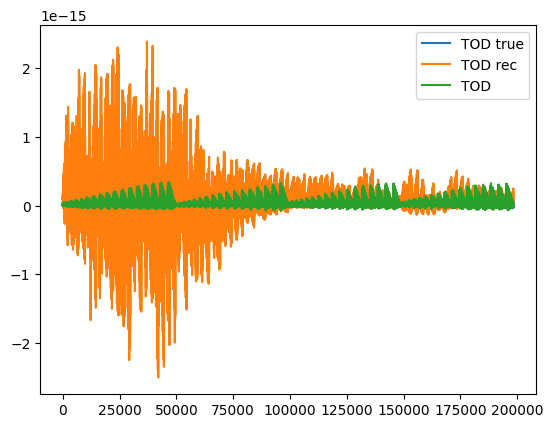

In [ ]:
maps_rec = P(maps_rec)
plt.plot(H(true_maps), label="TOD true")
plt.plot(H(maps_rec), label="TOD rec")
plt.plot(tod, label="TOD")
plt.legend()

print(np.mean(H(maps_rec) - tod))
print(np.mean(H(true_maps) - tod))

# Convergence & Plot

ValueError: Input could not be cast to an at-least-1D NumPy array

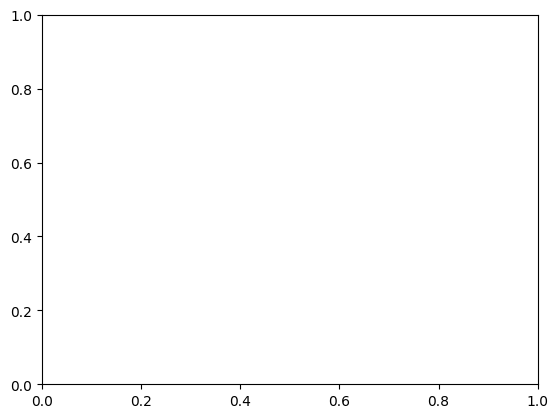

In [ ]:
plt.plot(convergence)
plt.title("Polychromatic")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Convergence")

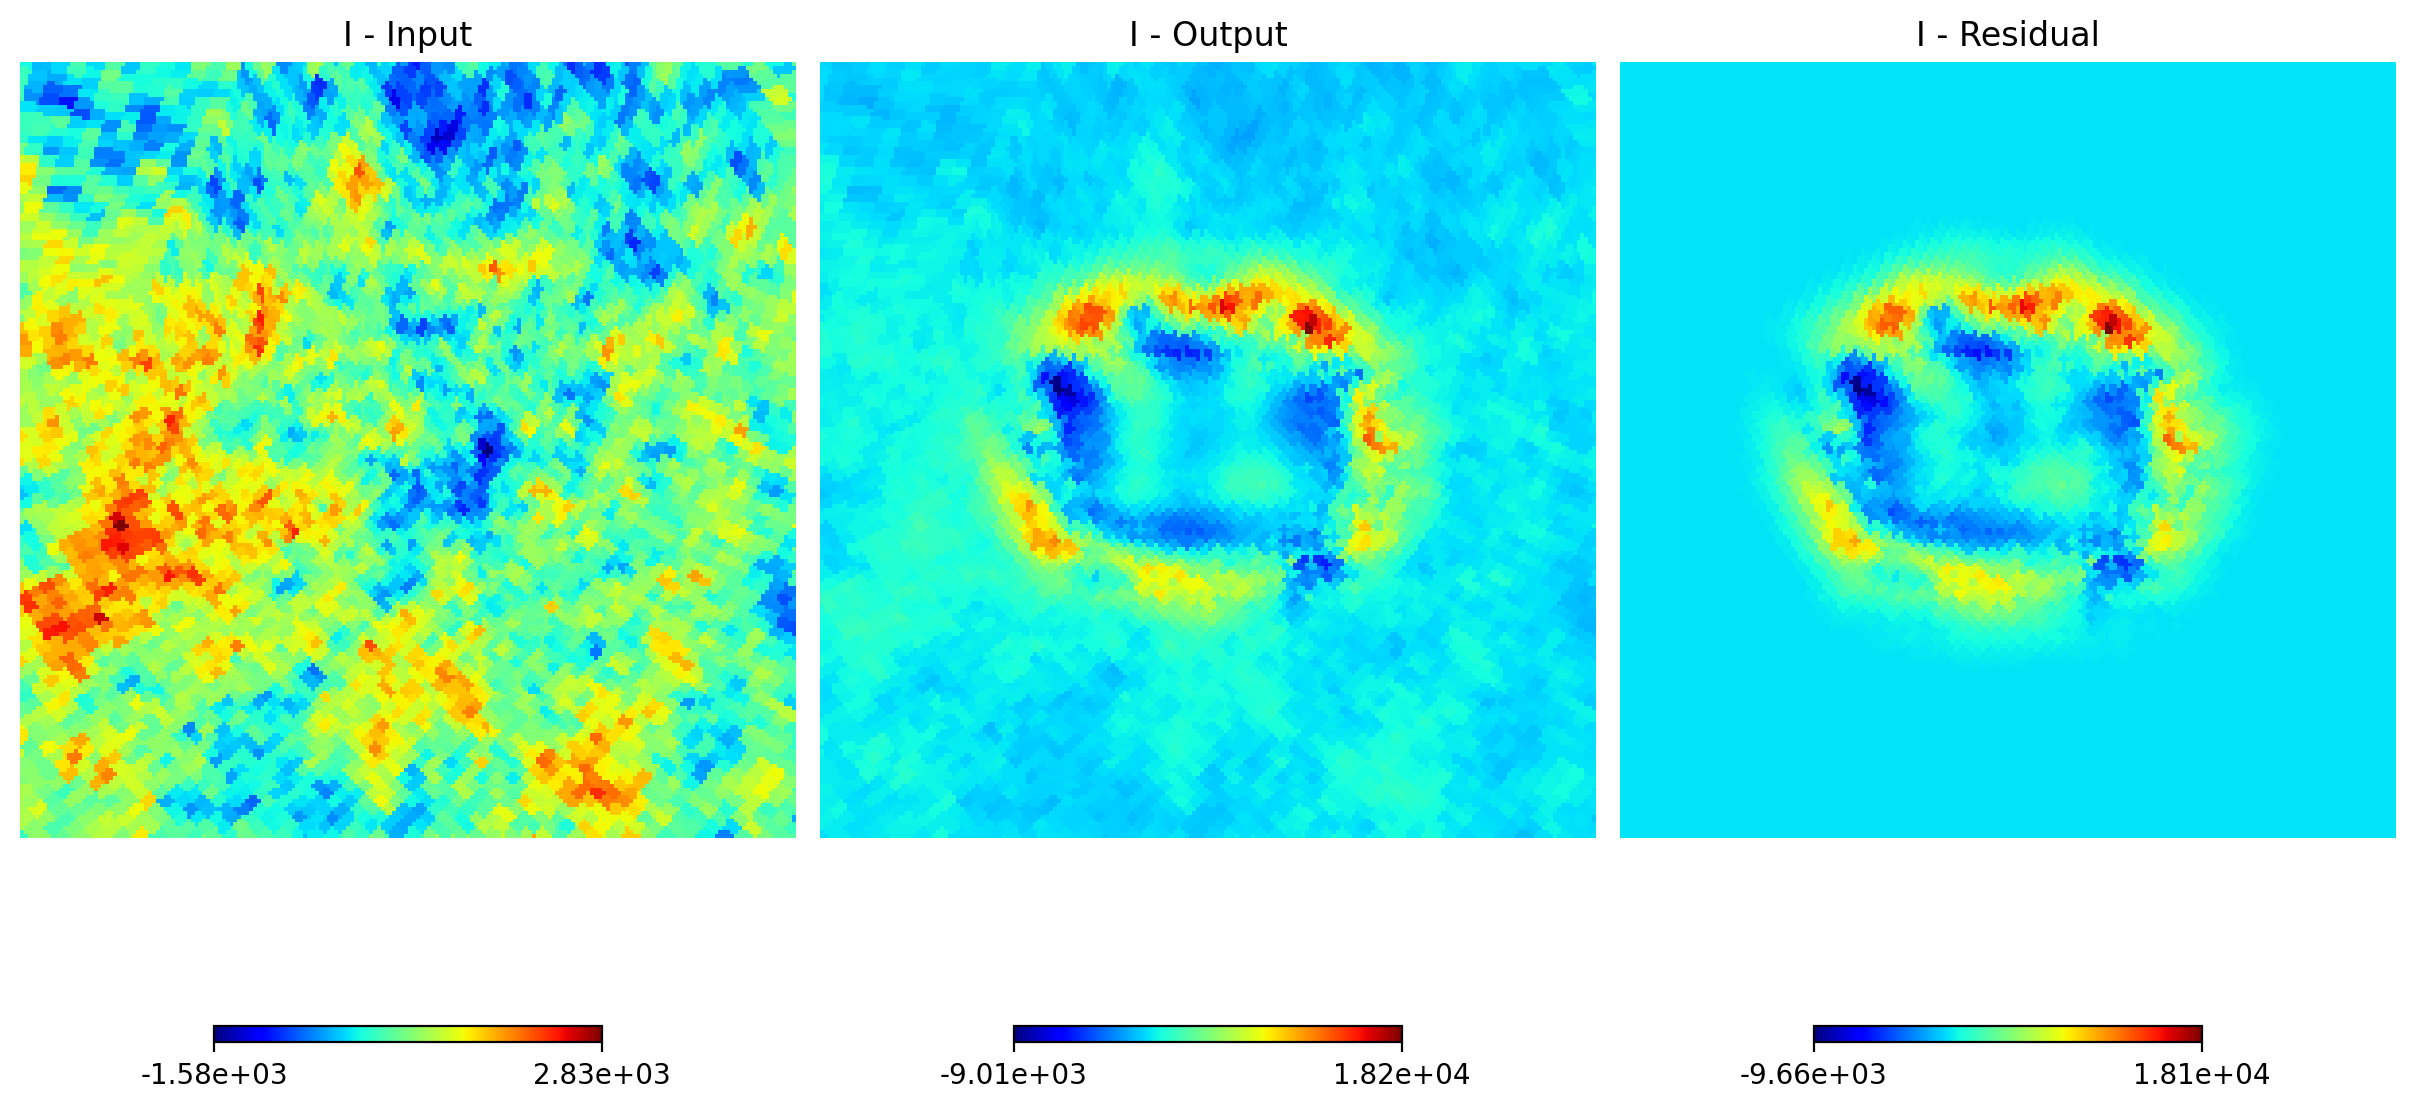

In [ ]:
plt.figure(figsize=(12, 12), dpi=200)
k = 1
# true_maps[:, ~seenpix, :] = hp.UNSEEN
# output['x'][:, ~seenpix, :] = hp.UNSEEN

stk = ["I", "Q", "U"]
istk = 0
n_sig = 3
reso = 25

for inu in range(maps_rec.shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.gnomview(
        true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Input".format(stk[istk]),
        reso=reso,
        sub=(maps_rec.shape[0], 3, k),
        notext=True,
    )
    hp.gnomview(
        maps_rec[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Output".format(stk[istk]),
        reso=reso,
        sub=(maps_rec.shape[0], 3, k + 1),
        notext=True,
    )
    hp.gnomview(
        maps_rec[inu, :, istk] - true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Residual".format(stk[istk]),
        reso=reso,
        sub=(maps_rec.shape[0], 3, k + 2),
        notext=True,
    )
    k += 3

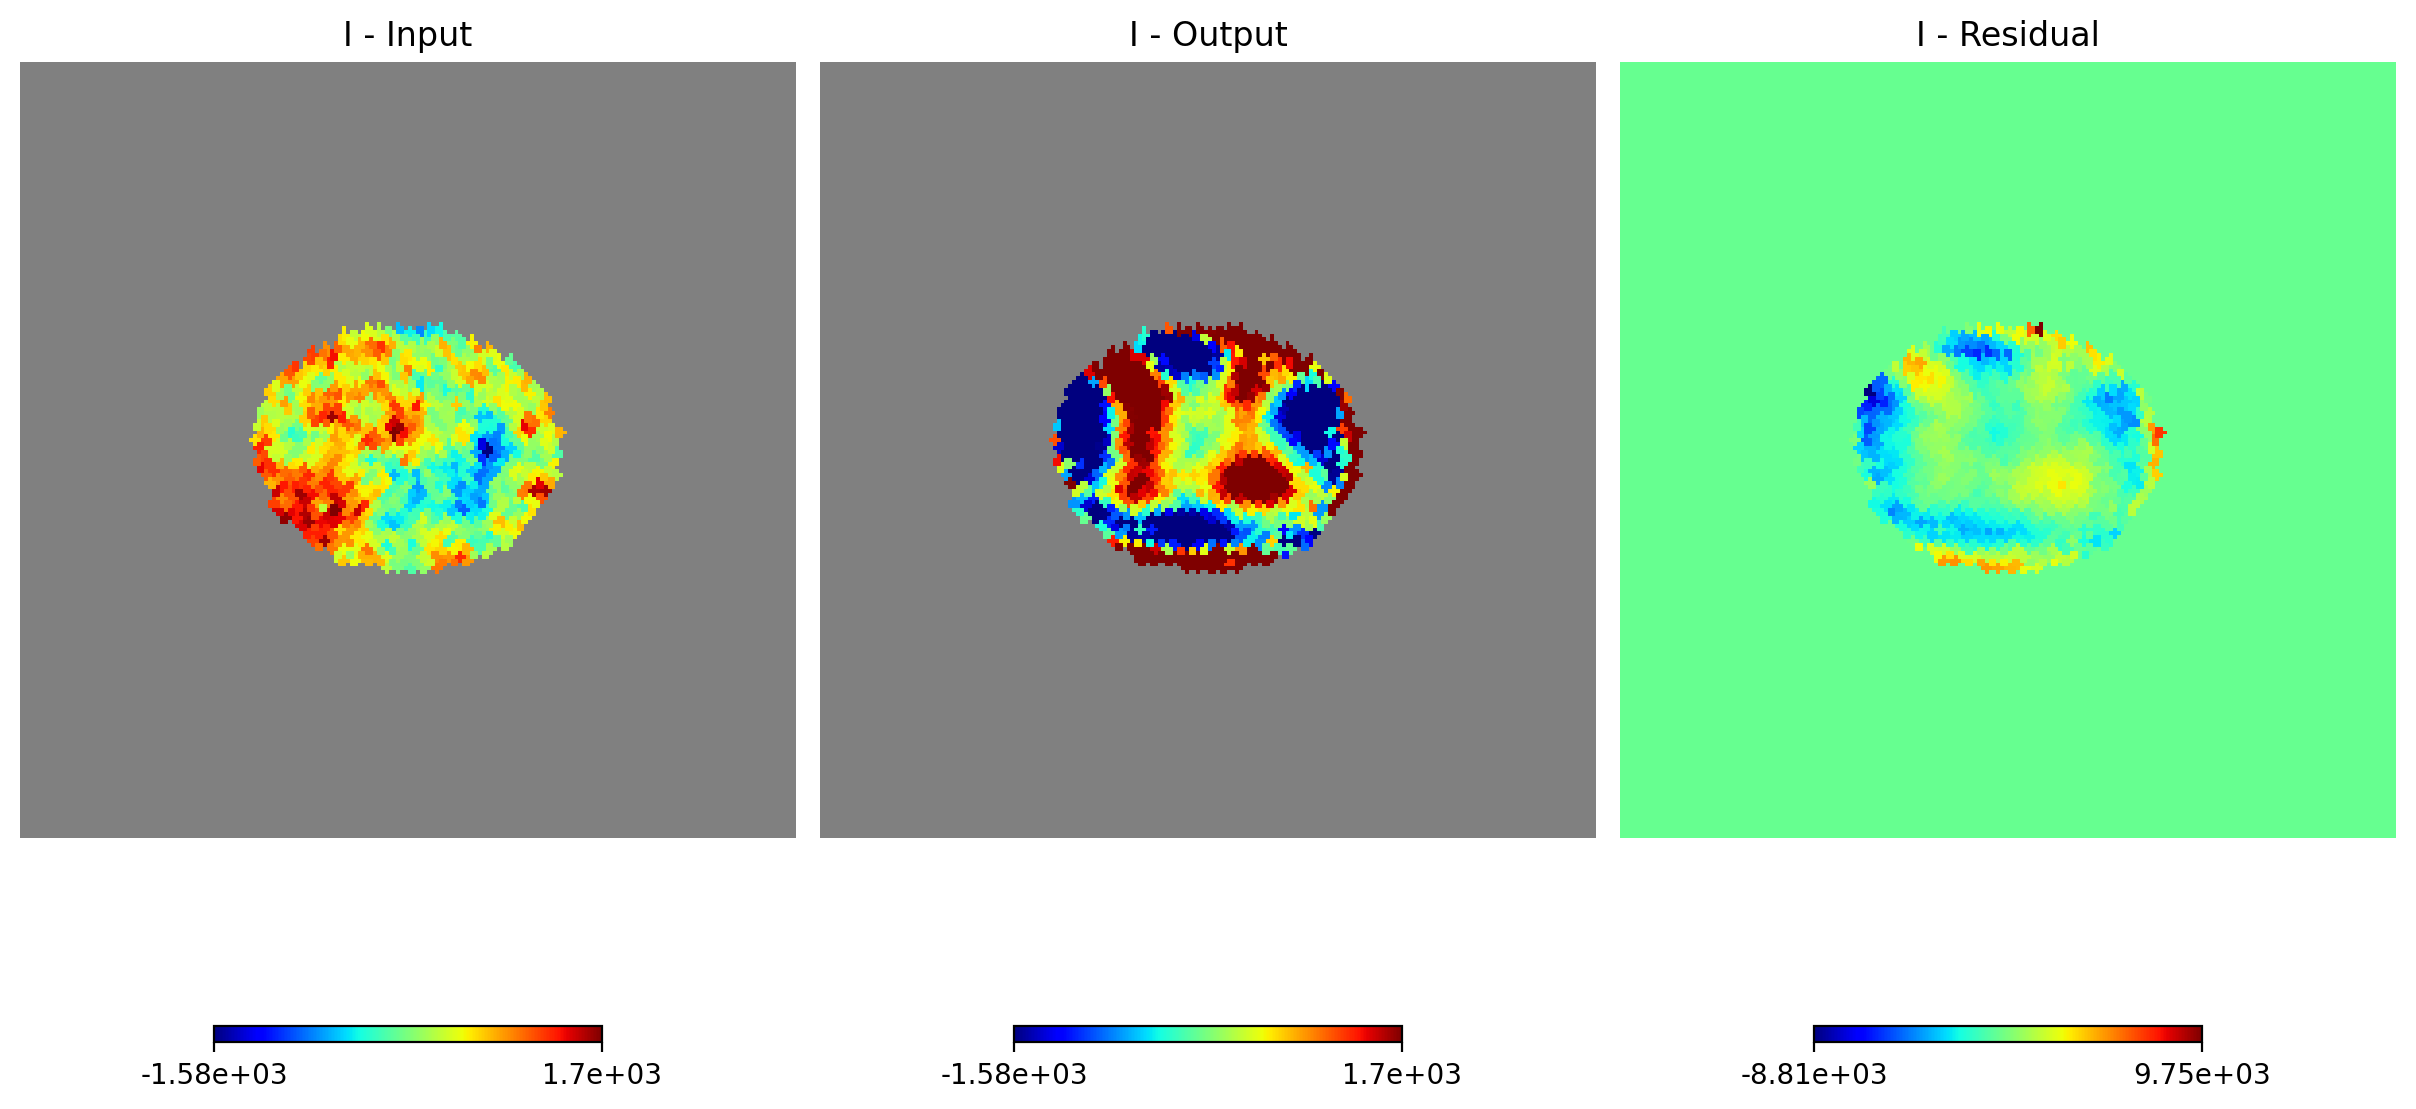

In [ ]:
plt.figure(figsize=(12, 12), dpi=200)
k = 1
true_maps[:, ~seenpix, :] = hp.UNSEEN
maps_rec[:, ~seenpix, :] = hp.UNSEEN

stk = ["I", "Q", "U"]
istk = 0
n_sig = 3
reso = 25

for inu in range(maps_rec.shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.gnomview(
        true_maps[inu, :, istk],
        min=np.min(true_maps[inu, seenpix, istk]),
        max=np.max(true_maps[inu, seenpix, istk]),
        cmap="jet",
        rot=center_local,
        title="{} - Input".format(stk[istk]),
        reso=reso,
        sub=(maps_rec.shape[0], 3, k),
        notext=True,
    )
    hp.gnomview(
        maps_rec[inu, :, istk],
        min=np.min(true_maps[inu, seenpix, istk]),
        max=np.max(true_maps[inu, seenpix, istk]),
        cmap="jet",
        rot=center_local,
        title="{} - Output".format(stk[istk]),
        reso=reso,
        sub=(maps_rec.shape[0], 3, k + 1),
        notext=True,
    )
    hp.gnomview(
        maps_rec[inu, :, istk] - true_maps[inu, :, 0],
        cmap="jet",
        rot=center_local,
        title="{} - Residual".format(stk[istk]),
        reso=reso,
        sub=(maps_rec.shape[0], 3, k + 2),
        notext=True,
    )
    k += 3

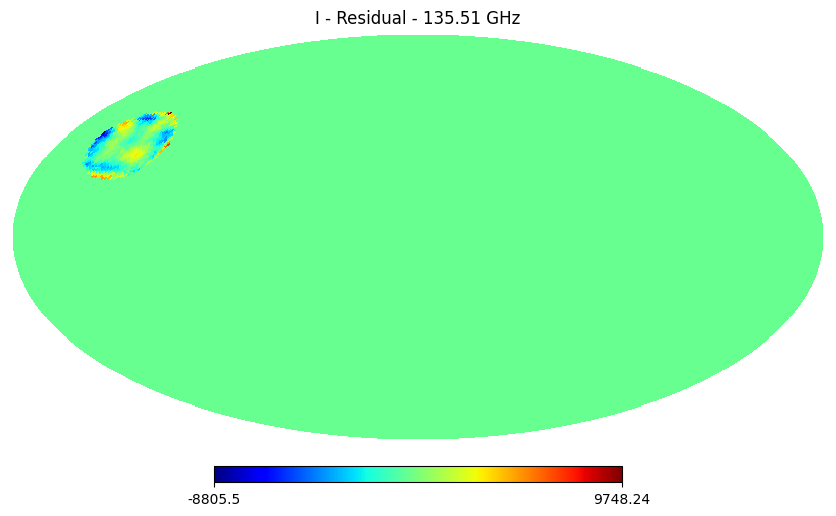

In [ ]:
for inu in range(maps_rec.shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.mollview(
        maps_rec[inu, :, istk] - true_maps[inu, :, istk],
        cmap="jet",
        title="{} - Residual - {:.2f} GHz".format(stk[istk], atm.frequencies[inu]),
    )

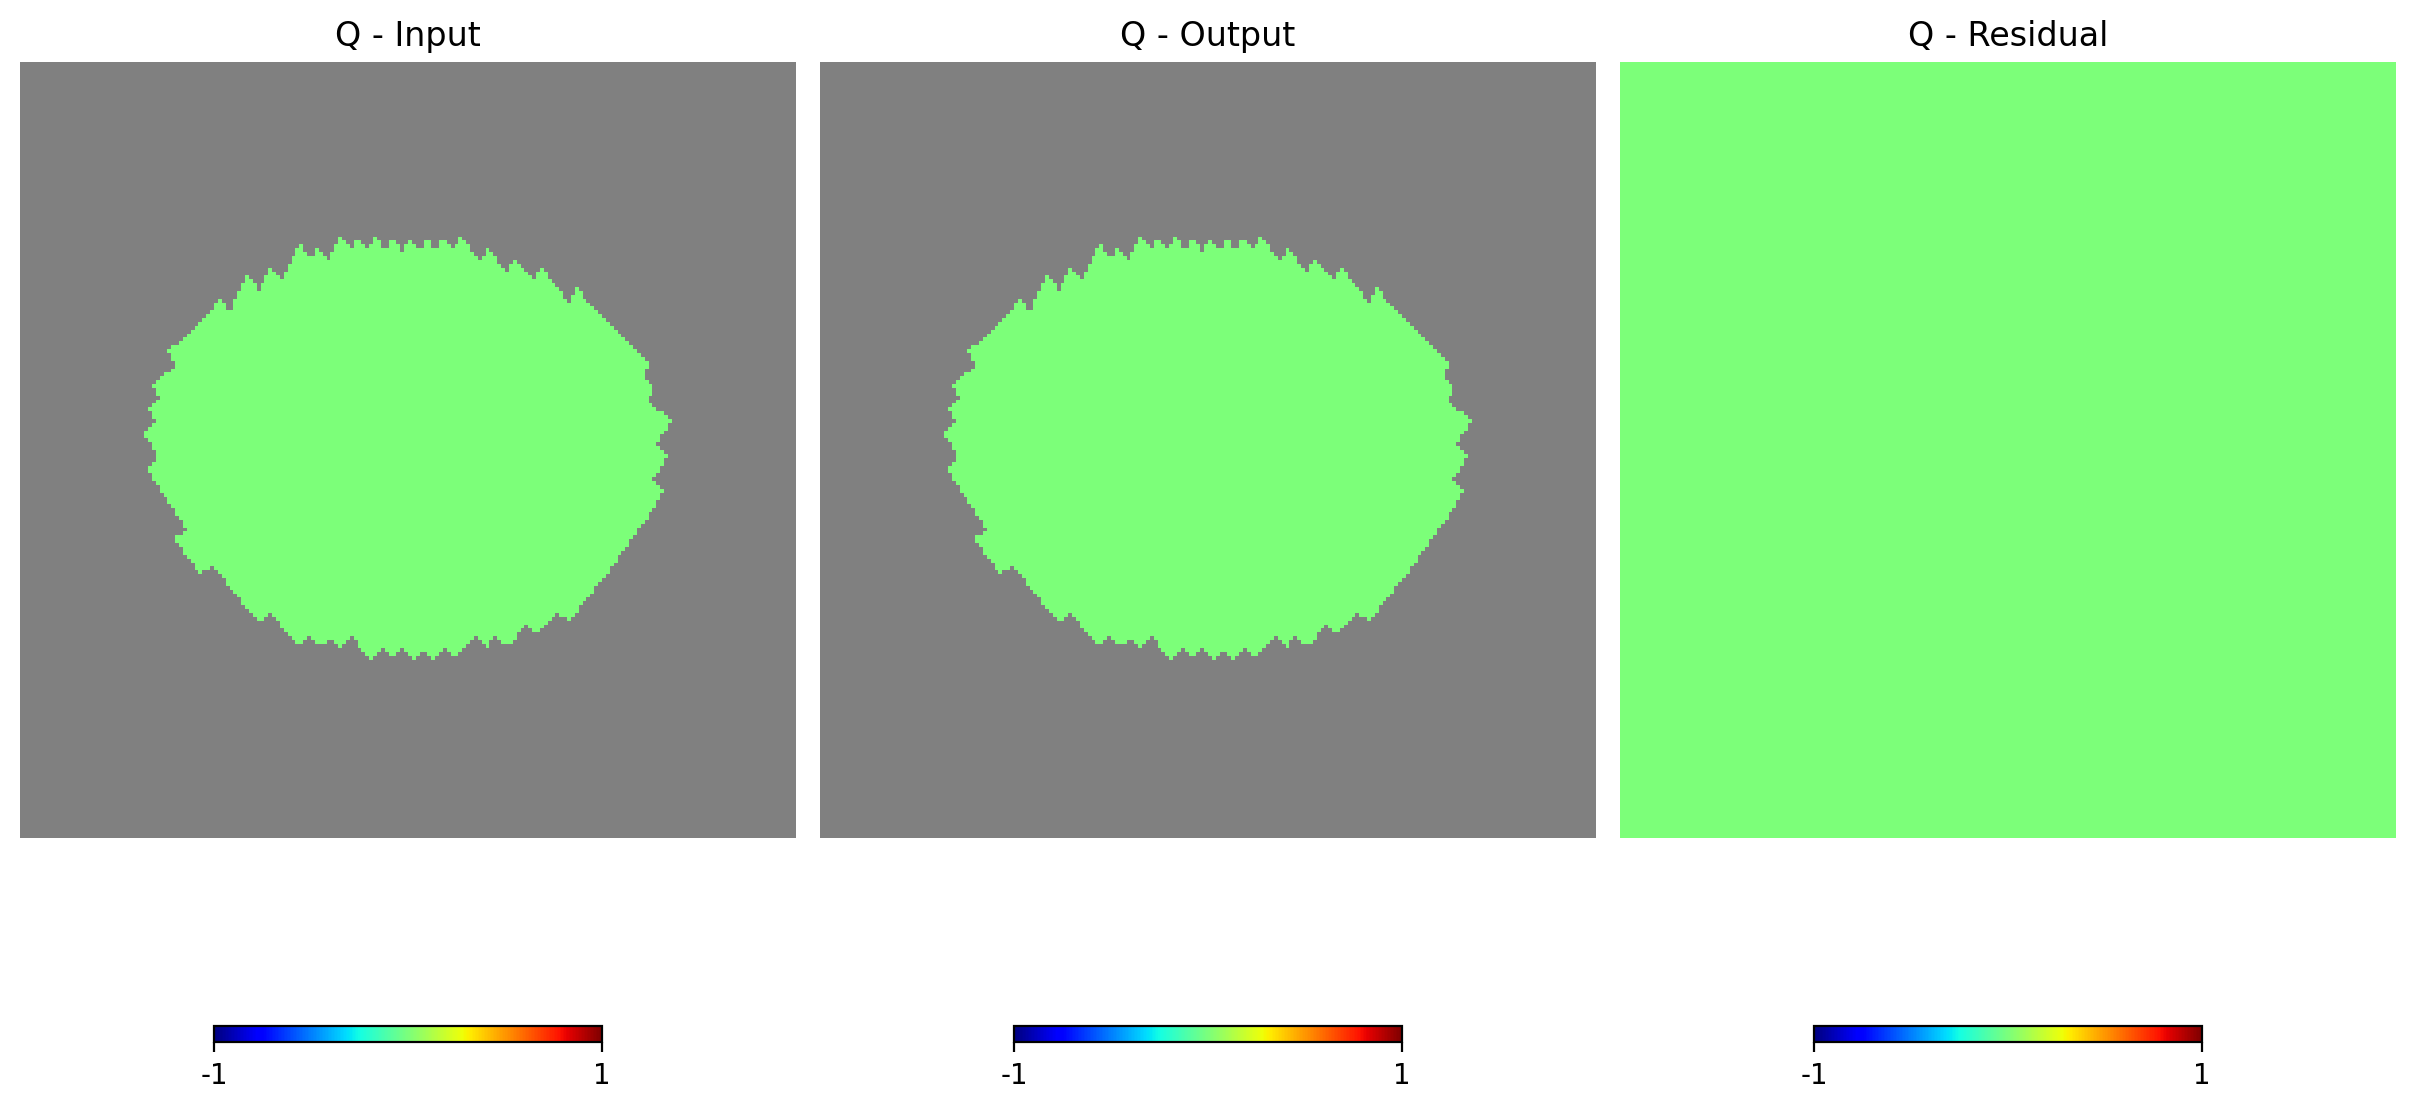

In [ ]:
plt.figure(figsize=(12, 12), dpi=200)

k = 1

istk = 1
n_sig = 2

for inu in range(maps_rec.shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.gnomview(
        true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Input".format(stk[istk]),
        reso=15,
        sub=(maps_rec.shape[0], 3, k),
        notext=True,
    )
    hp.gnomview(
        maps_rec[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Output".format(stk[istk]),
        reso=15,
        sub=(maps_rec.shape[0], 3, k + 1),
        notext=True,
    )
    hp.gnomview(
        maps_rec[inu, :, istk] - true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Residual".format(stk[istk]),
        reso=15,
        sub=(maps_rec.shape[0], 3, k + 2),
        notext=True,
    )
    k += 3